In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# For reproducibility
np.random.seed(42)

# Class 0
X0 = np.random.randn(50, 2) + np.array([2, 2])

# Class 1
X1 = np.random.randn(50, 2) + np.array([6, 6])

# Combine data
X = np.vstack((X0, X1))

# Labels
y = np.hstack((np.zeros(50), np.ones(50)))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 2)
Shape of y: (100,)


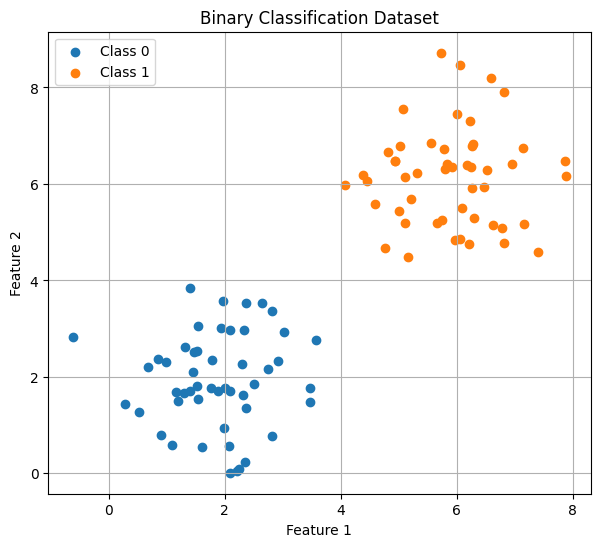

In [3]:
plt.figure(figsize=(7,6))

plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
# Number of features
n = X.shape[1]

# Initialize parameters
w = np.zeros(n)
b = 0.0

print("Weights:", w)
print("Bias:", b)

Weights: [0. 0.]
Bias: 0.0


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

In [9]:
probabilities = predict_probability(X, w, b)

print(probabilities[:])

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


Before learning begins, the model has no information, so it assigns 50% probability to every sample.

In [13]:
def compute_cost(X, y, w, b):
    """
    Computes Binary Cross-Entropy (Log Loss)
    """

    # Predicted probabilities
    y_pred = predict_probability(X, w, b)

    # Small value to avoid log(0) which is undefined
    # np.clip ensures forces all values in an array to stay within a specific range
    # Minimum bound: epsilon (1e-15) Maximum bound: 1 - epsilon (0.999999999999999)
    epsilon = 1e-15
    # It looks at every single number in the predicted prob and forces it to stay between epsilon and 1 - epsilon
    # This ensures they are never exactly 0 or 1, making the logarithm safe to compute.
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Compute loss for every sample
    loss = -(y * np.log(y_pred) +
             (1 - y) * np.log(1 - y_pred))

    # Average loss
    cost = np.mean(loss)

    return cost

In [14]:
cost = compute_cost(X, y, w, b)

print(cost)

0.6931471805599453


In [15]:
def compute_gradient(X, y, w, b):
    """
    Computes gradients of Logistic Regression cost.
    """

    m = X.shape[0]

    # Forward pass
    y_pred = predict_probability(X, w, b)

    # Prediction error
    error = y_pred - y

    # Gradients
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db

In [16]:
dw, db = compute_gradient(X, y, w, b)

print("dw =", dw)
print("db =", db)

dw = [-1.01005569 -1.05301986]
db = 0.0


In [17]:
def gradient_descent(X, y, w, b, learning_rate, iterations):
    """
    Performs Gradient Descent.
    """

    cost_history = []

    for i in range(iterations):

        # Compute gradients
        dw, db = compute_gradient(X, y, w, b)

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Compute cost
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        # Print every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i:4d} | Cost = {cost:.6f}")

    return w, b, cost_history

In [18]:
n = X.shape[1]

w = np.zeros(n)
b = 0.0

In [25]:
learning_rate = 0.1
iterations = 10000

w, b, cost_history = gradient_descent(
    X,
    y,
    w,
    b,
    learning_rate,
    iterations
)

Iteration    0 | Cost = 0.008891
Iteration  100 | Cost = 0.008831
Iteration  200 | Cost = 0.008772
Iteration  300 | Cost = 0.008714
Iteration  400 | Cost = 0.008657
Iteration  500 | Cost = 0.008600
Iteration  600 | Cost = 0.008544
Iteration  700 | Cost = 0.008489
Iteration  800 | Cost = 0.008435
Iteration  900 | Cost = 0.008382
Iteration 1000 | Cost = 0.008329
Iteration 1100 | Cost = 0.008277
Iteration 1200 | Cost = 0.008226
Iteration 1300 | Cost = 0.008175
Iteration 1400 | Cost = 0.008125
Iteration 1500 | Cost = 0.008076
Iteration 1600 | Cost = 0.008027
Iteration 1700 | Cost = 0.007979
Iteration 1800 | Cost = 0.007932
Iteration 1900 | Cost = 0.007885
Iteration 2000 | Cost = 0.007839
Iteration 2100 | Cost = 0.007794
Iteration 2200 | Cost = 0.007749
Iteration 2300 | Cost = 0.007704
Iteration 2400 | Cost = 0.007660
Iteration 2500 | Cost = 0.007617
Iteration 2600 | Cost = 0.007574
Iteration 2700 | Cost = 0.007532
Iteration 2800 | Cost = 0.007490
Iteration 2900 | Cost = 0.007449
Iteration 

In [26]:
print("Weights:", w)
print("Bias:", b)

Weights: [1.89761306 1.69041837]
Bias: -13.988997553205397


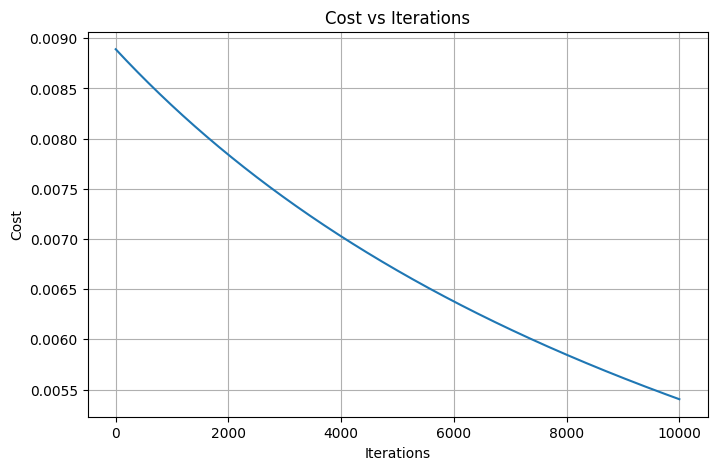

In [27]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)

plt.show()

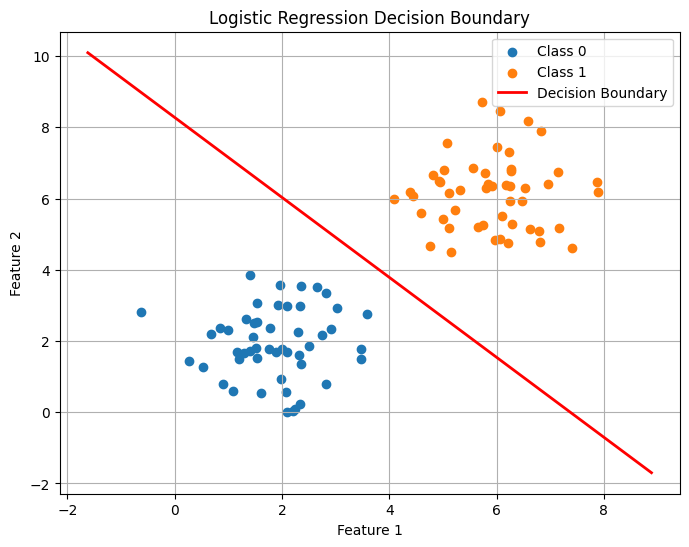

In [28]:
plt.figure(figsize=(8,6))

# Plot the data
plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

# Decision Boundary
x_values = np.array([X[:,0].min()-1,
                     X[:,0].max()+1])

y_values = -(w[0]*x_values + b)/w[1]

plt.plot(x_values, y_values,
         color="red",
         linewidth=2,
         label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
def predict(X, w, b):
    probabilities = predict_probability(X, w, b)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions

In [30]:
new_samples = np.array([
    [2,2],
    [6,6],
    [3,4],
    [7,5]
])

predictions = predict(new_samples, w, b)

print(predictions)

[0 1 0 1]


In [31]:
probabilities = predict_probability(new_samples, w, b)

for sample, prob in zip(new_samples, probabilities):
    print(f"{sample} -> Probability = {prob:.4f}")

[2 2] -> Probability = 0.0011
[6 6] -> Probability = 0.9995
[3 4] -> Probability = 0.1773
[7 5] -> Probability = 0.9996


In [32]:
y_pred = predict(X, w, b)
accuracy = np.mean(y_pred == y)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000
